In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Working with time series data - Gas prices

We will now explore some data which depends on time. Specifically, we have the data of gas prices at various Canadian locations over a period of time.

In [2]:
gp = pd.read_csv("../Files/1810000101_databaseLoadingData.csv", skipinitialspace=True)
gp

,REF_DATE,GEO,DGUID,Type of fuel,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2016-01,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,92.6,NaN,NaN,NaN,1
1,2016-02,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,86.7,NaN,NaN,NaN,1
2,2016-03,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,91.9,NaN,NaN,NaN,1
3,2016-04,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,100.0,NaN,NaN,NaN,1
4,2016-05,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,104.1,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2313,2025-10,"Yellowknife, Northwest Territories",2011A00056106023,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v735091,19.2,145.0,NaN,NaN,NaN,1
2314,2025-11,"Yellowknife, Northwest Territories",2011A00056106023,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v735091,19.2,144.3,NaN,NaN,NaN,1
2315,2025-12,"Yellowknife, Northwest Territories",2011A00056106023,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v735091,19.2,139.3,NaN,NaN,NaN,1
2316,2026-01,"Yellowknife, Northwest Territories",2011A00056106023,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v735091,19.2,133.9,NaN,NaN,NaN,1


In [3]:
gpGTA = gp[gp['GEO'] == 'Toronto, Ontario']
gpGTA['REF_DATE']

976     2016-01
977     2016-02
978     2016-03
979     2016-04
980     2016-05
         ...   
1093    2025-10
1094    2025-11
1095    2025-12
1096    2026-01
1097    2026-02
Name: REF_DATE, Length: 122, dtype: str

The GEO locations are repeated many times throughout the observations. How can we find the unique collection of place names?

In [4]:
places = gp.GEO.unique()
places

<StringArray>
[                                            'Canada',
              'St. John's, Newfoundland and Labrador',
 'Charlottetown and Summerside, Prince Edward Island',
                               'Halifax, Nova Scotia',
                          'Saint John, New Brunswick',
                                     'Québec, Quebec',
                                   'Montréal, Quebec',
      'Ottawa-Gatineau, Ontario part, Ontario/Quebec',
                                   'Toronto, Ontario',
                               'Thunder Bay, Ontario',
                                 'Winnipeg, Manitoba',
                               'Regina, Saskatchewan',
                            'Saskatoon, Saskatchewan',
                                  'Edmonton, Alberta',
                                   'Calgary, Alberta',
                        'Vancouver, British Columbia',
                         'Victoria, British Columbia',
                                  'Whitehorse, Yuko

In [5]:
gp[gp.GEO == 'Canada']

,REF_DATE,GEO,DGUID,Type of fuel,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2016-01,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,92.6,NaN,NaN,NaN,1
1,2016-02,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,86.7,NaN,NaN,NaN,1
2,2016-03,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,91.9,NaN,NaN,NaN,1
3,2016-04,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,100.0,NaN,NaN,NaN,1
4,2016-05,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,104.1,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2025-10,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,137.2,NaN,NaN,NaN,1
118,2025-11,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,139.6,NaN,NaN,NaN,1
119,2025-12,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,129.6,NaN,NaN,NaN,1
120,2026-01,Canada,2016A000011124,Regular unleaded gasoline at self service fill...,Cents per litre,57,units,0,v1352087861,20.2,130.4,NaN,NaN,NaN,1


### Plotting time series data

To start off, we want to put our dates into a more regular format.

In [6]:
gp['REF_DATE'] = pd.to_datetime(gp['REF_DATE'])

Now, we want to filter out the data for two particular cities in a certain time period.

In [7]:
date_range1 = (
    (gp['REF_DATE'] >= '2016-01-01') &
    (gp['REF_DATE'] <= '2018-12-01') &
    (gp['GEO'].isin(['Charlottetown and Summerside, Prince Edward Island','Toronto, Ontario']))
)

gp_dates1 = gp[date_range1]

Now, we want to pivot the data, in order to eventually graph it.

In [8]:
gp_dates1Data = gp_dates1.pivot(index='REF_DATE', columns='GEO', values='VALUE')

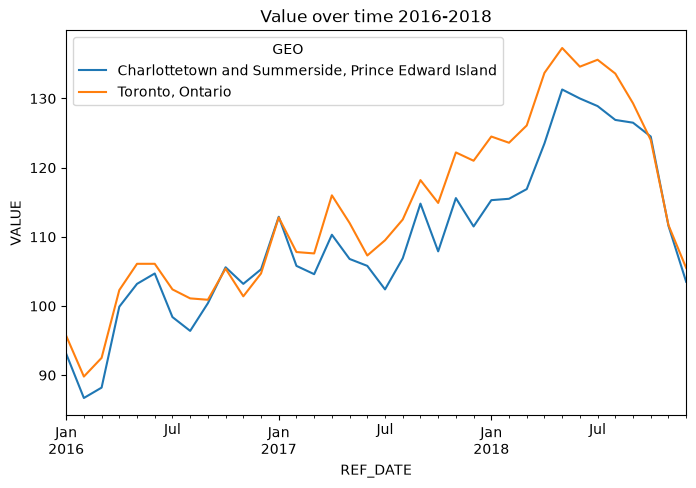

In [9]:
gp_dates1Data.plot(figsize=(8,5))
plt.ylabel("VALUE")
plt.title("Value over time 2016-2018")
plt.show()

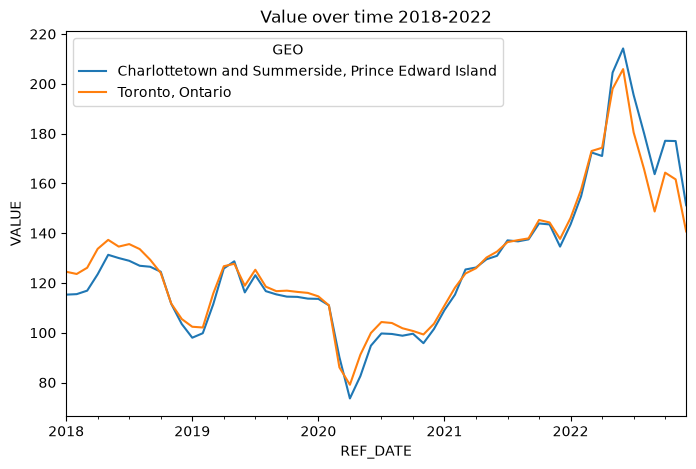

In [10]:
date_range2 = (
    (gp['REF_DATE'] >= '2018-01-01') &
    (gp['REF_DATE'] <= '2022-12-01') &
    (gp['GEO'].isin(['Charlottetown and Summerside, Prince Edward Island','Toronto, Ontario']))
)

gp_dates2 = gp[date_range2]
gp_dates2Data = gp_dates2.pivot(index='REF_DATE', columns='GEO', values='VALUE')
gp_dates2Data.plot(figsize=(8,5))
plt.ylabel("VALUE")
plt.title("Value over time 2018-2022")
plt.show()


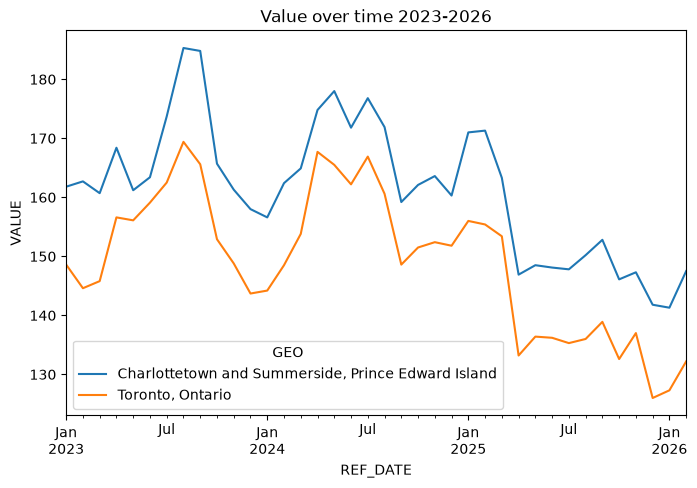

In [11]:
date_range3 = (
    (gp['REF_DATE'] >= '2023-01-01') &
    (gp['REF_DATE'] <= '2026-12-01') &
    (gp['GEO'].isin(['Charlottetown and Summerside, Prince Edward Island','Toronto, Ontario']))
)

gp_dates3 = gp[date_range3]
gp_dates3Data = gp_dates3.pivot(index='REF_DATE', columns='GEO', values='VALUE')
gp_dates3Data.plot(figsize=(8,5))
plt.ylabel("VALUE")
plt.title("Value over time 2023-2026")
plt.show()

### Question

We can now make some hypotheses about this data. 
- Maybe we notice that the price of gas in Charlottetown was on average lower than the price of gas in Toronto pre-Covid and is now higher post-Covid. 
- How could we support/disprove this hypothesis by further analyzing our data?